In [ ]:
#!pip install huggingface_hub
#!huggingface-cli login

In [ ]:
#import huggingface_hub

# Loggin to HF with code
#huggingface_hub.login()

## Import necessary libraries

In [ ]:
try:
  import datasets
  import gradio as gr
  import torchmetrics
  import pycocotools
except ModuleNotFoundError:

  # If a module isn't found, install it
  !pip install -U datasets gradio # -U stands for "upgrade" so we'll get the latest version by default
  !pip install -U torchmetrics[detection]

  import datasets
  import gradio as gr

  # Required for evaluation
  import torchmetrics
  import pycocotools # make sure we have this for torchmetrics

import random

import numpy as np

import torch
import transformers


## Getting a dataset

In [ ]:
from datasets import load_dataset

# Load our Trashify dataset
dataset = load_dataset(path="mrdbourke/trashify_manual_labelled_images")



In [ ]:
dataset["train"][42]

We can see the following features:
* `annotations` - a sequence of values including a `bbox` field as well as `category_id` field which contains the target objects we'd like to identify in our images.
* `image` - this contains the target image associated with a given set of `annotations`
* `image_id` - a unique ID assigned to a given sample
* `image_source` - where the image came from
* `label_source` - where the image label came from

### Explore our dataset

Rule of thumb:
* When downloading a new dataset, view 100 random samples (at least)
* Explore what each of the fields mean (whenever possible)

In [ ]:
from pprint import pprint

pprint(dataset["train"].features)

In [ ]:
# Get the categories from the dataset
# Note: Not all have this implemented when you download, it may be more of a manual process to find them
categories = dataset["train"].features["annotations"]["category_id"]

# Get the category names
categories.feature.names


### Creating a mapping from numbers to labels

Machines like numbers (hence they want to predict a number).

People like text(e.g. "bin")

So we create a mapping bettween the two.

When working with different categories, it’s good practice to get a list or mapping (e.g. a Python dictionary) from category name to ID and vice versa.

In [ ]:
# Map ID values to class names and viceversa
id2label = {i: class_name for i, class_name in enumerate(categories.feature.names)}
label2id = {value:key for key, value in id2label.items()}

id2label,label2id

### Creating a color palette

The data explorer's motto: *visualize, visualize, visualize!*

Let’s create a dictionary of different colours we can use to display our bounding boxes.

In [ ]:
# Make color dictionary = mapping from class names to RBG color
color_palette = {
    'bin': (0, 0, 224),         # Bright Blue (High contrast with greenery) in format (red, green, blue)
    'not_bin': (255, 80, 80),   # Light Red to indicate negative class

    'hand': (148, 0, 211),      # Dark Purple (Contrasts well with skin tones)
    'not_hand': (255, 80, 80),  # Light Red to indicate negative class

    'trash': (0, 255, 0),       # Bright Green (For trash-related items)
    'not_trash': (255, 80, 80), # Light Red to indicate negative class

    'trash_arm': (255, 140, 0), # Deep Orange (Highly visible)
}

Matplotlib displays colors in ranges of 0-1 instead of 0-255, that's is the reason we need to normalize our RBG values

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Normalize RBG values to 0-1
def normalize_rgb(rgb_tuple):
  return tuple(x/255.0 for x in rgb_tuple)


# Turn colors into normalized RGB values for matplotlib
colors_and_labels_rgb = [(key, normalize_rgb(value)) for key, value in color_palette.items()]


# Create a figure
fig, ax = plt.subplots(ncols=7, nrows=1, figsize=(8,1))

# Flatten the axes
ax = ax.flatten()

# Plot each color on a square
for idx, (label, color) in enumerate(colors_and_labels_rgb):
  ax[idx].add_patch(plt.Rectangle(xy= (0, 0),
                                  width = 1,
                                  height= 1,
                                  color=color))
  ax[idx].set_title(label)
  ax[idx].axis("off")

plt.tight_layout()
plt.show()

### Plotting a single image and visualize the boxes

#### Creating helper functions to view our images and boxes

To save some space in our notebook (plotting many images can increase the size of our notebook dramatically), we’ll create two small helper functions:

1. `half_image` - Halves the size of a given image.
2. `half_boxes` - Divides the input coordinates of a given input box by

In [ ]:
import PIL

def half_image(image: PIL.Image) -> PIL.Image:
  """
  Resized a given input image by half and returns the smaller version
  """
  return image.resize(size=(image.size[0] //2, image.size[1] //2))


In [ ]:
seven_image = dataset["train"][7]["image"]
seven_image

In [ ]:
half_seven_image = half_image(seven_image)
half_seven_image

In [ ]:
# Inspect a single bounding box
dataset["train"][7]["annotations"]["bbox"][0]

This array give us the coordiantes of a single bounding box in the format XYWH.

Where:

* `X` is the x-coordinate of the top left corner of the box.
* `Y` is the y-coordinate of the top left corner of the box.
* `W` is the width of the box.
* `H` is the height of the box.

In [ ]:
import numpy as np

def half_boxes(boxes):
  """
  Halves an array/tensor of input boxes and returns them. Neccesary for plotting
  boxes and half images.

  For example:
  boxes = [100, 100, 100, 100]
  boxes_half = half_boxes(boxes = boxes)
  print(boxes_half)
  # Output: [50, 50, 50, 50]
  """

  # Work with list/list of lists
  if isinstance(boxes, list):
    # If boxes are list of lists, then we have multiple boxes
    for box in boxes:
      if isinstance(box, list):
        return [[coordinate // 2 for coordinate in box] for box in boxes]

      else:
        return [coordinate //2 for coordinate in boxes]

  # Work with numpy arrays
  if isinstance(boxes, np.ndarray):
    return boxes // 2

  # Work with torch tensors
  if isinstance(boxes, torch.Tensor):
    return boxes // 2

In [ ]:
example_boxes_seven = dataset["train"][7]["annotations"]["bbox"]
example_boxes_seven

In [ ]:
half_boxes(boxes = example_boxes_seven)

In [ ]:
# Test our helper functions
example_image_seven = dataset["train"][7]["image"]
example_image_seven_half = half_image(example_image_seven)

print(f"[INFO] Original image size: {example_image_seven.size}")
print(f"[INFO] New image size: {example_image_seven_half.size}")

# Test our half boxes function
example_boxes_list = [[200,200,200,200],
                      [300,300,300,300]]

example_boxes_list_half = half_boxes(boxes = example_boxes_list)


example_boxes_torch = torch.tensor([[100,100,100,100],
                                   [200,200,200,200]])
example_boxes_torch_half = half_boxes(boxes = example_boxes_torch)

print(f"[INFO] Original boxes: {example_boxes_list}\nHalved: {example_boxes_list_half}")
print()
print(f"[INFO] Original boxes: {example_boxes_torch}\nHalved: {example_boxes_torch_half}")

### Plotting a single image with bouding boxes step by step

Working towards our 100 samples.

1. Select a random sample from our `dataset`.
2. Get the image from the `"image"`.
  * Optionally: half the image/boxes.
3. Turn the box coordinates into a `torch.tensor` (we will use `torchvision` to help plot our boxes).
4. Convert our box format from `XYWH` to `XYXY` using `torchvision.ops.box_convert` (this is because `torchvision.utils.draw_bounding_boxes` requires `XYXY` format).
5. Get a list of label names from the `category_id` field
6. Draw the target boxes onto the target image:
  * Turn or PIL image into tensors with `torchvision.transformers.functional.pil_to_tensor`
  * Once we've got a tensor, we can draw boxes with `torchvision.utils.draw_bounding_boxes`.
  * Turn the image and draw boxes from tensor back to `PIL` image: `torchvision.transformers.functional.to_pil_image`.


>**Note:** This is only one way to draw boxes. There are other ways such as using `matplotlib` or specialized helper libraries such as Roboflow's `supervision`.

>
> Our boxes are known to be in `XYWH` format and absolute pixel values. If you don't know what format your boxes are in at the start of a project, this will be one of your first steps because it will influence visualization and model training.




  

In [ ]:
dataset["train"][0]["annotations"]["bbox"][0]
# this coordinates are in XYWH

In [ ]:
# Plotting a bounding box on a single image
import random

import torch

from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes

from torchvision.transforms.functional import pil_to_tensor, to_pil_image

# 1. Select a random sample from our dataset
random_index = random.randint(0, len(dataset["train"]))
print(f"[INFO] Showing training sample from index: {random_index}")
random_sample = dataset["train"][random_index]

# 2. Get image and boxes from random sample
random_sample_image = random_sample["image"]
random_sample_boxes = random_sample["annotations"]["bbox"]

# Optional: Half the image and boxes for space saving (all of the following code will work with/without half size images)
half_random_sample_image = half_image(random_sample_image)
half_random_sample_boxes = half_boxes(random_sample_boxes)

# 3. Turn box coordinates in a tensor
boxes_xywh = torch.tensor(half_random_sample_boxes)
print(f"Boxes in XYWH format: {boxes_xywh}")

# 4. Convert boxes from XYWH -> XYXY
# torchvision.utils.draw_bounding_boxes requires input boxes in XYXY format (X_min, y_min, X_max, y_max)
boxes_xyxy = box_convert(boxes=boxes_xywh,
                         in_fmt="xywh",
                         out_fmt="xyxy")
print(f"Boxes XYXY: {boxes_xyxy}")

# 5. Get label names of target boxes and colours to match
random_sample_label_names = [id2label[x] for x in random_sample["annotations"]["category_id"]]
random_sample_colors = [color_palette[label_name] for label_name in random_sample_label_names]
print(f"Label names: {random_sample_label_names}")
print(f"Colour codes: {random_sample_colors}")

# 6. Draw the boxes on the image as a tensor and then turn it into a PIL image
output_image = to_pil_image(
      pic=draw_bounding_boxes(
          image=pil_to_tensor(pic=half_random_sample_image),
          boxes=boxes_xyxy,
          colors=random_sample_colors,
          labels=random_sample_label_names,
          width=2,
          label_colors=random_sample_colors
      )
)

In [ ]:
output_image

## Different bounding box formats

One of the most important and sometimes confusing things you'll find in object detection projects is the format of the bounding boxes.

The first question you should often ask is:

* What format are my bounding boxes in?

Are they in `XYXY` or `XYWH`?

And are the coordinates abolute or normalized?

> **Notes:** to learn more on the different formats and how to plot them, read the following guide: https://www.learnml.io/posts/a-guide-to-bounding-box-formats/

Why do we do this?

1. Wrong box format = wrong visualizations
2. Wrong box format = poor model training


## Creating/getting and Object Detection

1. Build it ourselves from scratch - construct the model layer by layer
2. Get an existing model - use an existing model that has been proven to work on a similar problem and then customize it to our own use case (transfer learning) ✅
   * Note: this is typically the most common use case when starting with Hugging Face.
  

Places to get OD models:
  * `torchvision` - https://pytorch.org/vision/stable/models.html
  * Hugging Face models - https://huggingface.co/models?pipeline_tag=object-detection&sort=trending
  * Apache 2.0 object detection models - https://www.learnml.io/posts/apache-object-detection-models/

### Transfer learning

Transfer learning is the process of taking one model which has been trained on a similar dataset to your problem and customizing it to your own specific problem.

For example, an existing object detectio model pre-trained on C0C0 (common images in context), this dataset contains 118k images along with 80 classes and then customizing for Trashify.

### Download a model from the Hugging Face Hub

These are the details of the model we're using:
* Model: https://huggingface.co/PekingU/rtdetr_v2_r50vd
  * RT-DETRv2 = Real-Time Detection Transformer with a ResNet50 backbone


In [ ]:
import torch
import requests

from PIL import Image
from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

image_processor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_v2_r50vd")
model = RTDetrV2ForObjectDetection.from_pretrained("PekingU/rtdetr_v2_r50vd")

inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
     outputs = model(**inputs)

results = image_processor.post_process_object_detection(outputs, target_sizes=torch.tensor([(image.height, image.width)]), threshold=0.5)

label_names = []
for result in results:
     for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         print(f"{model.config.id2label[label]}: {score:.2f} {box}")

         label_names.append(model.config.id2label[label])


In [ ]:
results

In [ ]:
output_image = to_pil_image(
      pic=draw_bounding_boxes(
          image=pil_to_tensor(pic=image),
          boxes=results[0]["boxes"],
          #colors=random_sample_colors,
          labels=label_names,
          width=2,
          #label_colors=random_sample_colors
      )
)
output_image

### Inspecting our model layers

In [ ]:
default_model = RTDetrV2ForObjectDetection.from_pretrained("PekingU/rtdetr_v2_r50vd")


In [ ]:
model

Embed = short for embedding = embedding is a learned numerical representation of data

Embeddings in machine learning are numerical representations of real-world objects (like words, images, or users) as dense vectors in a continuous, lower-dimensional space. The primary goal is to transform complex, high-dimensional, and often non-numerical data into a format that machine learning models can easily process and understand.






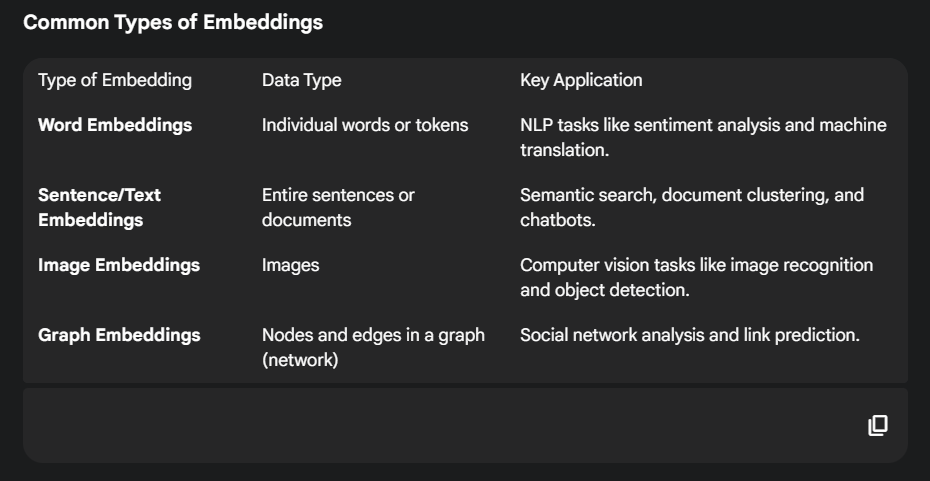

In [ ]:
len(model.config.id2label.items()), len(results[0]["boxes"][0])

Our model in its current for (straight downloades from HF) takes and input image and extracts patterns all to eventually lead to outputs:
* Class output = 80 numbers (1 per class)
* Box output = 4 numbers (XYXY)

In [ ]:
model.class_embed

### Counting Model Parameters

We can count the total number of parameters and the number of trainable parameters in the model.

In [ ]:
model.bbox_embed

### Counting the number of parameters in our model

Why do this?

Parameteres/weights/patterns = a learning opportunity for our model.

Generally, the more parameters, the higher learning capacity our model has to learn.

However, more parameters results in more storage and compute required to run our model.

If you are resource constrained (e.g. want to use a model on a mobile phone or if you have a small camera such a secury camera) you might want to limit parameter count.

>**Note:** This is here the "RT" in RT-DETR comes from, it's designed to be real-time, as it can run as 30fps+ on various hardware.

But if you have no compute constrains, go as big as you can.

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

parameter_counts = {
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": non_trainable_params
}

print(parameter_counts)

In [ ]:
def count_parameters(model):
  trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
  non_trainable_parameters = sum(p.numel() for p in model.parameters() if not p.requires_grad)
  total_parameters = trainable_parameters + non_trainable_parameters

  print(f"[INFO] Trainable parameters (updated during training): {trainable_parameters:,}\nNon-trainable: {non_trainable_parameters:,}\nTotal: {total_parameters:,}")
  return {"trainable_parameters": trainable_parameters,
          "non_trainable": non_trainable_parameters,
          "total_parameters":total_parameters}

original_model_parameter_counts = count_parameters(model)
original_model_parameter_counts

### Creating a function to create our own custom model

We've got a model that has been pre-trained on C0C0 (80 classes) but we want to customize our model to work on 7 classe for Trashify.


* Docs to RT-DETRv2 model - https://huggingface.co/docs/transformers/main/en/model_doc/rt_detr_v2

* Docs to RT-DETR preprocessor - https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessor

>**Note:** HF has the concept of "Auto Model" and "Auto Processor" which will automatically create a model/processor object depending on the input model/processor name.

In [ ]:
from transformers import AutoModelForObjectDetection

MODEL_NAME = "PekingU/rtdetr_v2_r50vd"

# Create a function to instantiate our own custom model
def create_model(pretrained_model_name_or_path: str = MODEL_NAME,
                 label2id: dict = label2id,
                 id2label: dict = id2label):
  """Creates and returns an instance of AutoModelForObjectDetection.

    Args:
        pretrained_model_name_or_path (str): The name or path of the pretrained model to load.
            Defaults to MODEL_NAME.
        label2id (dict): A dictionary mapping class labels to IDs. Defaults to label2id.
        id2label (dict): A dictionary mapping class IDs to labels. Defaults to id2label.

    Returns:
        AutoModelForObjectDetection: A pretrained model for object detection with number of output
            classes equivalent to len(label2id).
  """

  model = AutoModelForObjectDetection.from_pretrained(
      pretrained_model_name_or_path = MODEL_NAME,
      label2id = label2id,
      id2label = id2label,
      ignore_mismatched_sizes = True # we want to make sure that our model can load with our own custom output size
  )

  return model

custom_model = create_model()
custom_model

We get a warning output... however this is exactly what we want!
This warnig is because our model has a different number of target classes (7 in total) compared to he original model (91 in total, from the COCO datasset).

Our custom model now has an output layer that has the same number of outputs as our target dataset.


In [ ]:
print(f"[INFO] Final classification layer: {custom_model.class_embed}\n")
print(f"[INFO] Final box regression layer: {custom_model.bbox_embed}")

### Trying to pass a single sample through our model (Part 1)

An important step once you've got a model is to try and pass a single sample through it to examine the inputs and outputs.

Let's start by putting an image through our custom model (we'll start with the default image we loaded when we loaded our model).

In [ ]:
with torch.no_grad():
     outputs = custom_model(**inputs)

results = image_processor.post_process_object_detection(outputs,
                                                        target_sizes=torch.tensor([(image.height, image.width)]),
                                                        threshold=0.7)

label_names = []
for result in results:
     for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         print(f"{custom_model.config.id2label[label]}: {score:.2f} {box}")

         label_names.append(custom_model.config.id2label[label])


In [ ]:
output_image = to_pil_image(
      pic=draw_bounding_boxes(
          image=pil_to_tensor(pic=image),
          boxes=results[0]["boxes"],
          #colors=random_sample_colors,
          labels=label_names,
          width=2,
          #label_colors=random_sample_colors
      )
)
output_image

Now let's try pass a custom image from our own dataset through our model.

In [ ]:
half_image(dataset["train"][0]["image"])

In [ ]:
# if we try to pass a raw image to our custom model.. we get an error

#custom_model(half_image(dataset["train"][0]["image"]))

This error is because our model expects tensors as input!

Our images are in format `PIL.Image` rather than in `torch.FloatTensor` of shape `(batch_size, num_channels, height, width)`

So let's convert our image to a tensor then past it thought the model.

The `threshold` parameter means that the boxes under that number are suppressed, so that way we don't have like a million boxes

In [ ]:
custom_inputs = image_processor(images=half_image(dataset["train"][0]["image"]),
                                return_tensors="pt")


with torch.no_grad():
     custom_outputs = custom_model(**custom_inputs)

results = image_processor.post_process_object_detection(outputs,
                                                        target_sizes=torch.tensor([(half_image(dataset["train"][0]["image"]).height,
                                                                                    half_image(dataset["train"][0]["image"]).width)]),
                                                        threshold=0.7)

label_names = []
for result in results:
     for score, label_id, box in zip(result["scores"], result["labels"], result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         print(f"{custom_model.config.id2label[label]}: {score:.2f} {box}")

         label_names.append(custom_model.config.id2label[label])


In [ ]:
output_image = to_pil_image(
      pic=draw_bounding_boxes(
          image=pil_to_tensor(pic=half_image(dataset["train"][0]["image"])),
          boxes=results[0]["boxes"],
          #colors=random_sample_colors,
          labels=label_names,
          width=2,
          #label_colors=random_sample_colors
      )
)
output_image

## Aside: Data -> Preprocessor -> Model paradigm/workflow

This is a common pattern in all of machine learning.

And especially common in HF workflows.

It's an important step to **preprocesss our custom data into the same format our model was pre-trained on.**lk

Without doing this, we will likely get:

1. Errors
2. Poor results (because the model was trained on one kind of data but our data is in a different format)


For our specific model the preprocessor is RTDetrImageProcessor that is like the tokenizer for text.

In [ ]:
import torch
import requests

from PIL import Image
#from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
from transformers import AutoModelForObjectDetection, AutoImageProcessor

# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open(requests.get(url, stream=True).raw)

# image_processor = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_v2_r50vd")
# model = RTDetrV2ForObjectDetection.from_pretrained("PekingU/rtdetr_v2_r50vd")

image_processor_auto = AutoImageProcessor.from_pretrained("PekingU/rtdetr_v2_r50vd",
                                                          use_fast = True)
model_auto = AutoModelForObjectDetection.from_pretrained("PekingU/rtdetr_v2_r50vd")

In [ ]:
id2label

In [ ]:
(dataset["train"][0])

In [ ]:
# # Load input samples
# input_image = half_image(dataset["train"][0]["image"])
# input_label = dataset["train"][0]["annotations"]


# # Preprocess input samples for model
# sample_processed = image_processor_auto.preprocess(images = input_image,
#                                                     annotations = annotations)

# # Pass the preprocessed samples through our model
# model_outputs = model_auto(sample_processed)
# model_outputs

### Loading our model's preprocessor

We can see the documentation for our image processor here: https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessor

In [ ]:
from transformers import AutoImageProcessor

MODEL_NAME = "PekingU/rtdetr_v2_r50vd"

# Load the image processor
image_processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path=MODEL_NAME,
                                                     use_fast = True)

# Check out the image processor
image_processor

Notice the format of our data:

* Data format: pixel values will be: color_channels, height, width ->CHW
  * Some libraries use the format: HWC (Tensorflow)

*  "`format"`: "coco_detection"
```
"size": {
  "height": 640,
  "width": 640,
}
```

Our model has been pretrained on 640x640 size images.

What would happen if we used 224x224 to fine-tune our model?

For all the parameters, see the documentation:
* `do_pad` - https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessor.preprocess.do_pad

In [ ]:
# Set image size
IMAGE_SIZE = 640

# Create a new image_processsor instance with our own custom settings
image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    use_fast = True,
    format = "coco_detection", # our processor wants data in the C0C0 format
    do_convert_annotations = True, # this is the default value, this will convert our input annotations from C0C0 -> CXCYWH inr normalized format
    size = {"shortest_edge": IMAGE_SIZE,
            "longest_edge": IMAGE_SIZE}, # this will make sure our input image has a longest size of 640 whilst mainint aspect/ratio
    return_segmentation_mask = False,
    do_pad = True # this will make sure all images in a batch will have the same size, for example, if one image is (640.489), but the max
                    # dimension is (640,640) the smaller image will get padded with 0's to be (640,640)


)

In [ ]:
random_sample["image"]

In [ ]:
random_image_preprocessed = image_processor.preprocess(images = random_sample["image"],
                                                       #annotations = random_sample["annotations"]
                                                       )

When we try to preprocess our default image and annotation pairs, we can get an error:
> ValueError: Invalid COCO detection annotations. Annotations must a dict (single image) or list of dicts (batch of images) with the following keys: `image_id` and `annotations`, with the latter being a list of annotations in the COCO format.

In [ ]:
print(f"[INFO] Our preprocessed sample shape: {random_image_preprocessed['pixel_values'].shape} -> [batch_size, color_channels, height, width]")

In [ ]:
print(f"[INFO] Original image size: {random_sample['image'].size} -> (width, height) ")

For pixel value formats, something to note:
* If your image is in PIL format, the `size` attribute comes in `(width, height)`
* If your image is in torch.tensor format, it will generally come in `(color_channels, height, width)`

## Preprocessing an annotation for our samples

### Discuss the format our preprocessor/models expects our annotations

The reason why we spent so much time on preparing/preprocessing our data is because with data in the wrong format = poor results/errors.

We have:
* `category_id`= id2label keys

Our current format:
```
{'file_name': ['ee1c7f96-61c1-4d30-8667-c96f6c917d70.jpeg',
  'ee1c7f96-61c1-4d30-8667-c96f6c917d70.jpeg',
  'ee1c7f96-61c1-4d30-8667-c96f6c917d70.jpeg',
  'ee1c7f96-61c1-4d30-8667-c96f6c917d70.jpeg'],
 'image_id': [606, 606, 606, 606],
 'category_id': [5, 1, 0, 0],
 'bbox': [[372.29998779296875, 566.0999755859375, 265.0, 258.6000061035156],
  [473.79998779296875,
   673.4000244140625,
   475.3999938964844,
   578.2000122070312],
  [154.3000030517578,
   316.20001220703125,
   614.7000122070312,
   629.7000122070312],
  [2.799999952316284, 337.3999938964844, 319.5, 673.5999755859375]],
 'iscrowd': [0, 0, 0, 0],
 'area': [68529.0, 274876.28125, 387076.59375, 215215.203125]}
 ```
But the preprocessor/model expects the COCO format: https://cocodataset.org/#format-data

We want the format:

```
annotation{
"id": int,
"image_id": int,
"category_id": int,
"segmentation": RLE or [polygon],
"area": float,
"bbox": [x,y,width,height],
"iscrowd": 0 or 1,
}

categories[{
"id": int,
"name": str,
"supercategory": str,
}]

```



In [ ]:
random_annotations = random_sample["annotations"]
random_annotations

### Creating dataclasses to represent the COCO bouding box format

Dataclasses are a great Python tool to store a specific structure of data.

See the documentation - https://docs.python.org/3/library/dataclasses.html

COCO wants one dictionary per annotation:

```
annotation{
"id": int,
"image_id": int,
"category_id": int,
"segmentation": RLE or [polygon],
"area": float,
"bbox": [x,y,width,height],
"iscrowd": 0 or 1,
}
```

In [ ]:
from dataclasses import dataclass, asdict
from typing import List, Tuple

# 1. Create a dataclass for a single COCO annotation
@dataclass
class SingleCOCOAnnotation:
    """An instance of a single COCO annotation.

    Represent a COCO-formatted (see: https://cocodataset.org/#format-data) single instance of an object
    in an image.

    Attributes:
        image_id: Unique integer identifier for the image which the annotation belongs to.
        category_id: Integer identifier for the target object label/category (e.g. "0" for "bin").
        bbox: List of floats containing target bounding box coordinates in absolute XYWH format ([x_top_left, y_top_left, width, height]).
        area: Area of the target bounding box. Defaults to 0.0.
        iscrowd: Boolean flag (0 or 1) indicating whether the target is a crowd of objects, for example, a group of
            apples rather than a single apple. Defaults to 0.
    """
    image_id: int
    category_id: int
    bbox: List[float] # bboxes in XYWH format ([x_top_left, y_top_left, width, height])
    area: float = 0.0
    iscrowd: int = 0

    # Make sure the bbox is always a list of 4 values (XYWH format)
    def __post_init__(self):
        if len(self.bbox) != 4:
            raise ValueError(f"bbox must contain exactly 4 values, current length: {len(self.bbox)}")


# 2. Create a dataclass for a collection of COCO annotations for a single image
@dataclass
class ImageCOCOAnnotations:
    """A collection of COCO annotations for a single image_id.

    Attributes:
        image_id: Unique integer identifier for the image which the annotations belong to.
        annotations: List of SingleCOCOAnnotation instances.
    """
    image_id: int
    annotations: List[SingleCOCOAnnotation]

In [ ]:
asdict(SingleCOCOAnnotation(image_id = 42,
                     category_id = 0,
                     bbox = [100,100,100,100]))

### Creating to format our annotations as COCO format

Why not save the dataset originally in COCO format?

The answer is...

The annotation tool used here stored in a different format.

However, some annotation tools can export to COCO format.

But...

It's good practice to get familiar with formatting data in and out of the target format you need.

Because not all dataset (including ours) will come ready to use with a model.

Especially for objecto detection problems.

So we practice, practice, practice formatting data for our model.

--

Let's create a funcion to:

1. Take in the attributes of a single sample (in our format)
2. Convert it to COCO format using our dataclasses above
3. Return a single sample of our data in COCO format.

In [ ]:
# 1. Take in a unique image_id as well as lists of categories, areas, and bounding boxes
def format_image_annotations_as_coco(
        image_id: int,
        categories: List[int],
        areas: List[float],
        bboxes: List[Tuple[float, float, float, float]] # bboxes in XYWH format ([x_top_left, y_top_left, width, height])
) -> dict:
    """Formats lists of image annotations into COCO format.

    Takes in parallel lists of categories, areas, and bounding boxes and
    then formats them into a COCO-style dictionary of annotations.

    Args:
        image_id: Unique integer identifier for an image.
        categories: List of integer category IDs for each annotation.
        areas: List of float areas for each annotation.
        bboxes: List of tuples containing bounding box coordinates in XYWH format
            ([x_top_left, y_top_left, width, height]).

    Returns:
        A dictionary of image annotations in COCO format with the following structure:
        {
            "image_id": int,
            "annotations": [
                {
                    "image_id": int,
                    "category_id": int,
                    "bbox": List[float],
                    "area": float
                },
                ...more annotations here
            ]
        }

    Note:
        All input lists much be the same length and in the same order.
        Otherwise, there will be mismatched annotations.
    """

    # 2. Turn input lists into a list of dicts in SingleCOCOAnnotation format
    coco_format_annotations = [
        asdict(SingleCOCOAnnotation(
            image_id=image_id,
            category_id=category,
            bbox=list(bbox),
            area=area,
        ))
        for category, area, bbox in zip(categories, areas, bboxes)
    ]

    # 3. Return a of annotations with format {"image_id": ..., "annotations": [...]} (required COCO format)
    return asdict(ImageCOCOAnnotations(image_id=image_id,
                                       annotations=coco_format_annotations))

In [ ]:
ramdom_sample = dataset["train"][18]
ramdom_sample

In [ ]:
ramdom_sample_image_id = random_sample["image_id"]
ramdom_sample_categories = random_sample["annotations"]["category_id"]
ramdom_sample_areas = random_sample["annotations"]["area"]
ramdom_sample_bboxes = random_sample["annotations"]["bbox"]

# Try our function to format our annotation in COCO format
random_sample_coco_annotations = format_image_annotations_as_coco(image_id = ramdom_sample_image_id,
                                                                 categories = ramdom_sample_categories,
                                                                 areas = ramdom_sample_areas,
                                                                 bboxes = random_sample_boxes)
random_sample_coco_annotations

In [ ]:
random_sample["image"]

### Preprocess a single image and its COCO formated annotations

In [ ]:
random_sample_preprocessed = image_processor(images=ramdom_sample["image"],
                                            annotations = random_sample_coco_annotations,
                                             do_convert_annotations = True)

In [ ]:
from pprint import pprint

pprint(random_sample_preprocessed.labels[0])

* `boxes` - Our previous boxes were in XYWH absolute format, now they are in CXCYWH normalize format, this can be seen in the `do_convert_annotations` parameters in the RTDetrImageProcessor documentation - https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessorFast.preprocess.do_convert_annotations

* `area` - the values of our bounding boxes
* `class_labels` - the labels of each of our boxes (see `id2label`)
* `image_id` - the global image ID for a given sample
* `orig_size` - the original size of our input image in (`height, width)` format
* `size` - the converted size out of preprocess in (`height, width)` format
* `is_crowd` - an array/tensor of a boolean value (0 or 1) for whether an annotation is a group or not.




Up next: Post processing a single output...

Data -> Preprocessor -> Model -> Postprocessor

See the documentation for post processing: https://www.learnhuggingface.com/notebooks/hugging_face_object_detection_tutorial#postprocessing-a-single-output

## Postprocessing a single sample

Tip: it's always a good idea to try and to go end to end on a single sample. For example take a raw sample (our data), preprocess it, pass it through the model, then post process it.

The function we'll use to post-process our model's output is `post_process_object_detection` - https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessor.post_process_object_detection

In [ ]:
random_sample_outputs = custom_model(pixel_values = random_sample_preprocessed["pixel_values"])
#random_sample_outputs

In [ ]:
type(random_sample_outputs)

In [ ]:
random_sample_preprocessed["labels"][0]["orig_size"]

In [ ]:
# Set the threshold
THRESHOLD = 0.60

# Post process a single output from our model
random_sample_outputs_post_processed = image_processor.post_process_object_detection(
    outputs = random_sample_outputs,
    threshold = THRESHOLD,
    target_sizes = random_sample_preprocessed["labels"][0]["orig_size"].unsqueeze(0),

)

#random_sample_outputs_post_processed

We get an output of:
* `scores` = model's confidence/prediction probability of a given box
* `labels` = model's predicted label ID
* `boxes` = boxes in the form `XYXY` in absolute format

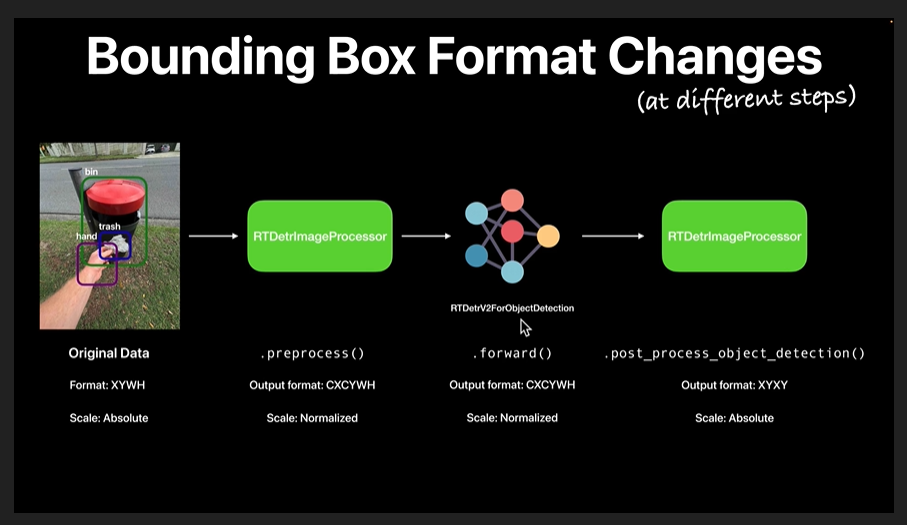

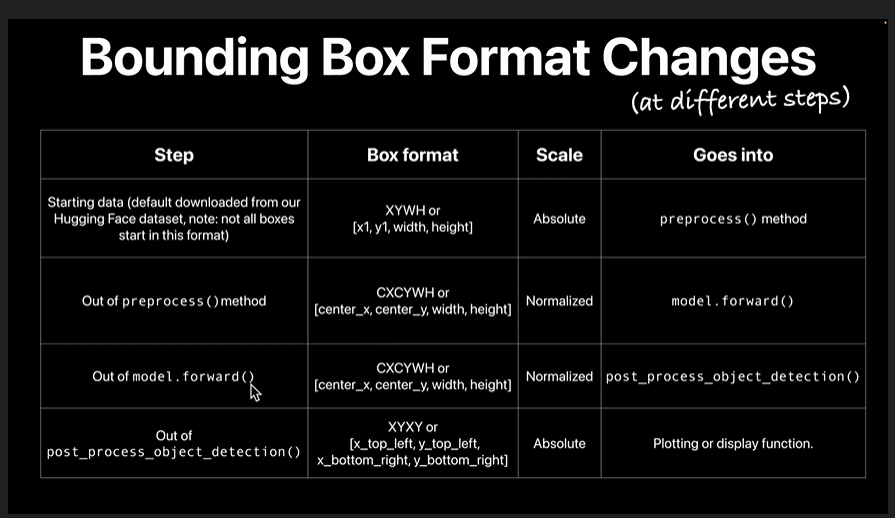

### Plotting our model's post processed predictions on our image

In [ ]:
# Get target image and boxes (half them for display purposes in the notebook)
image_to_plot = half_image(random_sample["image"])
boxes_to_plot = half_boxes(random_sample_outputs_post_processed[0]["boxes"])

# Collect the boxes, scores and labels
random_sample_label_names = []
for result in random_sample_outputs_post_processed:
     for score, label_id, box in zip(result["scores"],
                                     result["labels"],
                                     result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         # Optionally print out each prediction
         # print(f"[INFO] {model.config.id2label[label]}: {score:.2f} {box}")

         random_sample_label_names.append(custom_model.config.id2label[label])

# Get the list of colours to plot
random_sample_colours = [color_palette[label_name] for label_name in random_sample_label_names]
# print(f"Label names: {random_sample_label_names}")
# print(f"Colour codes: {random_sample_colours}")

# Create the output image with plotted boxes
output_image_with_boxes = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=image_to_plot),
        boxes=boxes_to_plot,
        labels=random_sample_label_names,
        colors=random_sample_colours,
        width=3,
        label_colors=random_sample_colours
    )
)
output_image_with_boxes

## Preparing data at scale

Let's do the following steps to prepare our data at scale:

1. Splitting the data into traininin, validation and tests sets
2. Preprocess many samples at one time (e.g. rather than 1x sample like we've already done, we want to make preprocessing multiple samples possible)
3. Collate our samples into batches (or at least define a function that does so)

### Splitting the data into train and test sets

We want our model to *hopefully* generalize to unseen training samples.

To evaluate our model's ability to perfom on unseen samples, we'll split our data into three sets:

1. Training set (~70-80% of your data) - This is like the course material in university preparing before the exam/real world
2. Validation set (~5-20% of data)- this is like the practice exam in university before the real test, we can adjust our model's settings/hyparameters on the results we see here.
3. Test set (~5-20% of your data) - this is like the final exam in a university course/the first problems your model will see in the real world.

In [ ]:
# Let's check our original dataset
from datasets import load_dataset

dataset = load_dataset("mrdbourke/trashify_manual_labelled_images")
original_dataset_length = len(dataset["train"])
dataset

In [ ]:
print(f"[INFO] Right now we have {original_dataset_length} training samples")

We can split our dataset into target splits using the `train_test_split()` method from Hugging Face dataset - https://huggingface.co/docs/datasets/en/package_reference/main_classes#datasets.Dataset.train_test_split

In [ ]:
# 1. Split the data into train and test splits
dataset_split = dataset["train"].train_test_split(test_size = 0.3, seed = 42)
dataset_split

In [ ]:
dataset_test_val_split = dataset_split["test"].train_test_split(test_size=0.66, seed=42) # split the test set into 40/60 validation/test
dataset_test_val_split

In [ ]:
dataset_split

In [ ]:
dataset["train"] = dataset_split["train"]
dataset["validation"] = dataset_test_val_split["train"]
dataset["test"] = dataset_test_val_split["test"]

dataset

### Writing a function for preprocessing multiple samples at a time

We've preprocessed one sample end-to-end.

But now we need an effective way to do multiple samples simultaneously.

Accordint to the `preprocess` method, it can preprocess multiple samples at a time as long as we pass them in as list of samples: https://huggingface.co/docs/transformers/en/model_doc/rt_detr#transformers.RTDetrImageProcessor.preprocess

We need:
* a list of images
* a list of annotations in COCO format, lucky we have our `format_image_annotations_as_coco` function to turn our raw annotation data into COCO format.

In [ ]:
group_of_samples = dataset["train"][0:3]
group_of_samples

**Something to note:** Hugging Face Datasets is built on Apache Arrow, this database is column-like in style rather than row-like. Rather of get a list of , we get a dictionary of lists.

* See doc here: https://huggingface.co/docs/datasets/en/about_arrow

We need our function to turn of a given samples from our dataset into the format our `preprocess` method wants.

Why preprocess a bunch of samples at a time?

Generally, it's more efficient to preprocess or perfomr te same operation on a group of samples at the same time rather than just one by one.

Especially for GPU computing, you want to spend as little time as possible transfering data and more time using GPU computs.

Let's start writing our function:

1. Take a list of examples (these will be in the raw sata format, or our original data format), and `image_processor` instance and optional `transforms` (we can use these transforms for data augmentation)
2. Create empty list of `images` and `coco_annotations`.
3. Extract the `image`, `image_id` and `annotations_dict` from our list of input examples.
4. Createa list of annotations attributes such as `bbox`, `category_id` and `area` (these are required for our `format_image_annotations_as_coco` funtion).
5. Optionally perform transforms/augmentatioins on our image + annotations (**note:** in object detection if you transform your image, you must tranform your annotations as well) - https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_getting_started.html#sphx-glr-auto-examples-transforms-plot-transforms-getting-started-py
6. Convert the annotations into COCO format using the `format_image_annotations_as_coco`.
7. Append the images and COCO format to the empty list we created in step 2.
8. Pass the list of images and COCO formated anootations to the `image_processor.preprocess` method to get the preprocessed batch of examples.
9. Return the preprocessed batch

In [ ]:
# 1. Take in a list of examples, image processor and optional transforms
def preprocess_batch(examples,
                     image_processor,
                     transforms=None, # Note: Could optionally add transforms (e.g. data augmentation) here
                     ):
    """
    Preprocesses a batch of image data with annotations for object detection models.

    This function takes a batch of examples in a custom dataset format, extracts images and
    their corresponding annotations, and converts them into a format suitable for model training
    or inference using the provided image processor.

    Args:
        examples (dict): A dictionary containing the batch data with the following structure:
            - "image" (List[PIL.Image.Image]): List of PIL Image objects
            - "image_id" (List[int]): List of unique image identifiers
            - "annotations" (List[dict]): List of annotation dictionaries, where each contains:
                - "file_name" (List[str]): List of image filenames
                - "image_id" (List[int]): List of image identifiers
                - "category_id" (List[int]): List of object category IDs
                - "bbox" (List[List[float]]): List of bounding boxes as [x, y, width, height]
                - "iscrowd" (List[int]): List of crowd indicators (0 or 1)
                - "area" (List[float]): List of object areas
            - "label_source" (List[str]): List of label sources
            - "image_source" (List[str]): List of image sources

        image_processor: An image processor object to preprocess images for model input.
            For example, can be `transformers.RTDetrDetrImageProcessor`.

        transforms (optional): Image and annotations transforms for data augmentation.
            Defaults to None.

    Returns:
        dict: Preprocessed batch with images and annotations converted to tensors
            in the format required for a `transformers.RTDetrV2ForObjectDetection` model.

    Note:
        The `format_image_annotations_as_coco` function converts the input annotation format to COCO
        format before applying the image_processor. This is required as the image_processor is designed
        to handle COCO format annotations.
    """
    # 2. Create empty lists to store images and annotations
    images = []
    coco_annotations = []

    # 3. Extract the image, image_id and annotations from the examples
    for image, image_id, annotations_dict in zip(examples["image"],
                                                 examples["image_id"],
                                                 examples["annotations"]):

        # 4. Create lists of annotation attributes
        bbox_list = annotations_dict["bbox"]
        category_list = annotations_dict["category_id"]
        area_list = annotations_dict["area"]

        ###
        # 5. Note: Could optionally apply a transform/augmentation here.
        # See PyTorch docs for more: https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_e2e.html
        if transforms:
            # Perform transform on image/boxes
            pass
        ###

        # 6. Format the annotations into COCO format
        coco_format_annotations = format_image_annotations_as_coco(image_id=image_id,
                                                                   categories=category_list,
                                                                   areas=area_list,
                                                                   bboxes=bbox_list)

        # 7. Add images/annotations to their respective lists
        images.append(image) # Note: may need to open image if it is an image path rather than PIL.Image
        coco_annotations.append(coco_format_annotations)


    # 8. Apply the image processor to lists of images and annotations
    preprocessed_batch = image_processor.preprocess(images=images,
                                                    annotations=coco_annotations,
                                                    return_tensors="pt")

    # 9. Return the preprocessed batch
    return preprocessed_batch

In [ ]:
#print(f"[INFO] The shape of our preprocessed samples: {preprocessed_group_of_samples['pixel_values'].shape} -> [batch_size, color_channels, height, width]")

### Applying our preprocessing function to each data split

In [ ]:
from functools import partial

preprocess_batch_partial = partial(preprocess_batch,
                                   image_processor=image_processor,
                                   transforms=None) # could use transforms here if wanted

preprocess_batch_partial;

In [ ]:
# Apply our partial function to our datasets
processed_dataset = dataset.copy();

# Apply processing function
processed_dataset["train"] = processed_dataset["train"].with_transform(preprocess_batch_partial)
processed_dataset["validation"] = processed_dataset["validation"].with_transform(preprocess_batch_partial)
processed_dataset["test"] = processed_dataset["test"].with_transform(preprocess_batch_partial)

processed_dataset["train"][42]


In [ ]:
dataset["train"][42]

### Creating a collation function

So far we have:

* Funciton to preprocess our samples into COCO fomart ✅ -> apply that function to our dataset on te fly ✅ -> tell our samples how to stack together in a batch.

  * See doc here: https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.Trainer.data_collator

In [ ]:
from typing import List, Dict, Any

def data_collate_function(preprocessed_batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    """Stacks together groups of preprocessed samples into batches for our model.

    Args:
        preprocessed_batch: A list of dictionaries where each dictionary represnets a preprocessed sample.

    Returns:
        collated_data: A dictionary containing the batched data ready in the format our model
            is expecting. The dictionary has the following keys:
                - "pixel_values": A stacked tensor of preprocessed pixel values.
                - "labels": A list of label dictionaries.
                - "pixel_mask": (Optional) A stacked tensor of pixel masks (this will be present
                    only if the input contains a "pixel_mask" key.
    """
    # Create an empty dictionary (our model wants a dictionary input)
    collated_data = {}

    # Stack together a collection of pixel_values tensors
    # Docs for torch.stack - https://docs.pytorch.org/docs/stable/generated/torch.stack.html
    collated_data["pixel_values"] = torch.stack([sample["pixel_values"] for sample in preprocessed_batch])

    # Get the labels (these are dictionaries so no need to use torch.stack)
    collated_data["labels"] = [sample["labels"] for sample in preprocessed_batch]

    # If there is a pixel_mask key, return the pixel_mask's as well
    if "pixel_mask" in preprocessed_batch[0]:
        collated_data["pixel_mask"] = torch.stack([sample["pixel_mask"] for sample in preprocessed_batch])

    return collated_data

In [ ]:
%%time

# Try data_collate_function
example_collated_data_batch = data_collate_function(processed_dataset["train"].select(range(32)))
example_collated_data_batch.keys()

In [ ]:
# Check shapes of batched preprocessed samples
print(f"[INFO] Batch of pixel value shapes: {example_collated_data_batch['pixel_values'].shape}")
print(f"[INFO] Batch of labels: {example_collated_data_batch['labels']}")
if "pixel_mask" in example_collated_data_batch:
    print(f"[INFO] Batch of pixel masks: {example_collated_data_batch['pixel_mask'].shape}")

## Setting up TrainingArguments and a Trainer instance to train our model

Time to train a model!

To do so, we can go though the following steps:

0. Create an instance of our model to train, using `create_model()`

1. Set up TrainingArguments - these are like settings for our model training, many of them are set by default but there are some we can customize to suit our problem. See docs: https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments

2. Optional: Setup a custom optimizer for our training recipe (this is inline with the research papers).

3. Create an evaluation function to use throughout training, this will evaluate the patterns our model learns on the training set on the validatin set (these samples will be unseen)

4. Make an instance of `Trainer` to train our model, see docs: https://huggingface.co/docs/transformers/en/main_classes/trainer
 * Once we've instantiated our `Trainer` class, we can train our model on our custom data by calling `transformers.trainer.train()`. See docs: https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.Trainer.train

5. Plotting our model's loss curves (loss = measure how *wrong* your model is, ideally the loss goes down over time and our eval metric goes up).

------

* `TrainingArguments` = settings for your model + training recipe
* `Trainer` = the orchestrator for training a model

In [ ]:
# 1. Create an instance of our model to train
model = create_model()

In [ ]:
# 2. Make a directory to save model instances and checkpoint to
# During model training, we can tell our model to save to a file if it passes certain thresholds
# Eg if our model is the best performing over our training schedule, we can always make sure the best model gets saved
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

### Let's setup TrainingArguments

`transformers.TrainingArguments` = settings for our training recipe.

In other words, it contains many values for different hyperparametrs we can set for our model training.

Hyperparameters can be confusing because there are so many different settings...

Parameters = patterns the model learn on it's own

Hyperparameters = user defined settings

---

Where to get hyperparameters settings?

1. Use `transformers.TrainingArguments` default.
2. Investigate the research paper/repository where the model was introduced and copy the settings from there.
3. Experiment, experiment, experiment!

> **Note:** Just because a research paper set some good values for hyperparameters doesn't necessarily mean they'll work for your own problem,


In [ ]:
# Set up TraniningArguments
import os
from transformers import TrainingArguments

BATCH_SIZE = 8 # this is hardware dependent, usallya you will increase
DATALOADER_NUM_WORKERS = os.cpu_count() // 2

# Note: typically fine-tuning requieres less epochs than training from scratch
NUM_EPOCHS = 10

# Set up hyperparameters similar to the DETER paper(s)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0001
MAX_GRAD_NORM = 0.1
WARMUP_RATIO = 0.05 # warmup  for 5% of our training steps (don't try to learn too fast)


# Create directory and path to save models to
OUTPUT_DIR = Path(models_dir, "rt_detrv2_finetuned_trashify_box_detector_v1")
print(f"[INFO] Saving model to: {OUTPUT_DIR}")

# Create TrainingArguments to pass to Trainer
training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    num_train_epochs = NUM_EPOCHS,
    dataloader_num_workers = DATALOADER_NUM_WORKERS,
    learning_rate = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY,
    max_grad_norm = MAX_GRAD_NORM,
    warmup_ratio = WARMUP_RATIO,
    logging_strategy = "epoch",
    save_strategy = "epoch",
    save_total_limit = 2,
    fp16 = True,
    eval_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "eval_loss",
    greater_is_better = False, # for a loss metric, lower is better... for an eval metric such as mAP, higher is better
    report_to = "none", # don't log metrics to an experiment tracker, like weights & biases
    push_to_hub = False, # don't push model to hub
    eval_do_concat_batches = False,
    remove_unused_columns = False
)


### Optional: Setting up an optimizer for multiple learning rates

In [ ]:
from transformers import Trainer

# Trainer is our orchestrator of all the settings, data an model

# Create a list of parameters for different learning rates
backbone_parameters = []
other_parameters = []

# Can loop through our model parameters and extract different model sections
for name, param in model.model.named_parameters():
  if "backbone" in name:
    backbone_parameters.append(param)
  else:
    other_parameters.append(param)

print(f"[INFO] Number of layers with backbone parameters: {len(backbone_parameters)}")
print(f"[INFO] Number of layers without non-backbone parameters: {len(other_parameters)}")

BACKBONE_LEARNING_RATE = 1e-5
DETECTION_LEARNING_RATE = 1e-4

class CustomTrainer(Trainer):
  def create_optimizer(self):
    # See docs for torch optimizer
    self.optimizer = torch.optim.AdamW([
        {"params": backbone_parameters, "lr": BACKBONE_LEARNING_RATE},
        {"params": other_parameters, "lr": DETECTION_LEARNING_RATE}
    ],
    weight_decay=WEIGHT_DECAY)
    return self.optimizer


### Creating an evaluation function

We can check how well our model is doing by visualizing predictions.

But we want to quickly see perfomance via numbers.

Essentially we want an evaluation metric.

Evaluation metric = a single number that shows how well your model is doing.

In object detection, on the main evaluation metrics is mAP(Mean Average Precision) (higher is better).

We want to measure our model's mAP as it's training... this way we can see it's performance improving (or not) as we go.

For our evaluation function to calculate mAP,we need:
* A function to go into `compute_metrics_` for `Trainer` - https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.Trainer.compute_metrics
  * Our function should take in `EvalPrediction` - https://huggingface.co/docs/transformers/en/internal/trainer_utils#transformers.EvalPrediction
  * It should retunr a dictionary of string to metric (e.g. `{"metric_name:42...}`)
* To calculate mAP, we'll use torchmetrics - https://lightning.ai/docs/torchmetrics/stable/detection/mean_average_precision.html
* For mor about object detection metrics, see Roboflow's guide -
https://blog.roboflow.com/object-detection-metrics/

So our recipe is:
* Create a function
* To take model predictions
* Calculate mAP with torchmetrics
* Return a dictionary of metrics to name value
* These will be display during training

The main data structures we'll need are:
```
preds (List): A list consisting of dictionaries each containing the key-values (each dictionary corresponds to a single image). Parameters that should be provided per dict

boxes (Tensor): float tensor of shape (num_boxes, 4) containing num_boxes detection boxes of the format specified in the constructor. By default, this method expects (xmin, ymin, xmax, ymax) in absolute image coordinates, but can be changed using the box_format parameter. Only required when iou_type=”bbox”.

scores (Tensor): float tensor of shape (num_boxes) containing detection scores for the boxes.

labels (Tensor): integer tensor of shape (num_boxes) containing 0-indexed detection classes for the boxes.

masks (Tensor): boolean tensor of shape (num_boxes, image_height, image_width) containing boolean masks. Only required when iou_type=”segm”.
```
```
target (List): A list consisting of dictionaries each containing the key-values (each dictionary corresponds to a single image). Parameters that should be provided per dict:

boxes (Tensor): float tensor of shape (num_boxes, 4) containing num_boxes ground truth boxes of the format specified in the constructor. only required when iou_type=”bbox”. By default, this method expects (xmin, ymin, xmax, ymax) in absolute image coordinates.

labels (Tensor): integer tensor of shape (num_boxes) containing 0-indexed ground truth classes for the boxes.

masks (Tensor): boolean tensor of shape (num_boxes, image_height, image_width) containing boolean masks. Only required when iou_type=”segm”.

iscrowd (Tensor): integer tensor of shape (num_boxes) containing 0/1 values indicating whether the bounding box/masks indicate a crowd of objects. Value is optional, and if not provided it will automatically be set to 0.

area (Tensor): float tensor of shape (num_boxes) containing the area of the object. Value is optional, and if not provided will be automatically calculated based on the bounding box/masks provided. Only affects which samples contribute to the map_small, map_medium, map_large values
```



In [ ]:
from torchvision.ops import box_convert

def convert_bbox_cxcywh_to_xyxy_absolute(boxes,
                                         image_size_target):
    """
    Converts CXCYWH normalized boxes to XYXY absolute boxes.

    The output of our preprocess method puts boxes in CXCYWH format.

    But our evaluation metric torchmetrics.detection.mean_ap.MeanAveragePrecision expects
        boxes in XYXY absolute format.

    Args:
        boxes (torch.Tensor): A tensor of shape (N, 4) where N is the number of boxes and each box is in CXCYWH format.
        image_size_target (tuple): A tuple containing the target image size as (height, width).

    Returns:
        torch.Tensor: A tensor of shape (N, 4) where each box is converted to XYXY absolute format.
    """
    # Convert normalized CXCYWH (output of model) -> absolute XYXY format (required for evaluation)
    boxes = box_convert(boxes=boxes, in_fmt="cxcywh", out_fmt="xyxy")

    # Convert normalized box coordinates to absolute pixel values based on the target size
    image_size_target_height = image_size_target[0]
    image_size_target_width = image_size_target[1]
    boxes = boxes * torch.tensor([image_size_target_width,
                                  image_size_target_height,
                                  image_size_target_width,
                                  image_size_target_height]) # Multiply X coordinates by the width and Y coordinates by the height

    return boxes

To create our function, we'll go through the following steps:
0. Import libraries we need...
1. Create a Python `dataclass` to hold our model’s outputs. We could use a dictionary but this will give our code a bit more structure.
2. Create a `compute_metrics` function which takes in an `EvalPrediction` object as well as other required evaluation parameters such as `image_processor` (for post processing boxes), `id2label` (for mapping metrics to class names) and t`hreshold` (for assigning a prediction probability threshold to boxes).
3. Extract predictions and targets from `EvalPrediction` via `EvalPrediction.predictions` and `EvalPrediction.label_ids` respectively.
4. Create empty lists of `image_sizes` (for post processing boxes), `post_processed_predictions` and `post_processed_targets` (we’ll compare the latter two to each other).
5.Collect target samples in format required for `torchmetrics.detection.mean_ap.MeanAveragePrecision`, for example, `[{"boxes": [...], "labels": [...]}]`.
6. Collect predictions in the required formart for `MeanAveragePrecision`, our model produces boxes in CXCYWH format, then we use `image_processor.post_process_object_detection` to convert the predictions to XYXY format, and append them to `post_processed_predictions` in form `[{"boxes": [...], "labels": [...], "scores": [...]}]`.
7. Initialize an instance of `torchmetrics.detection.mean_ap.MeanAveragePrecision` (see documentation for output of `MeanAveragePrecision`) and pass it predictions and labels to compute on.
8. Extract lists of target metrics from the output of `MeanAveragePrecision`, for example, with `metrics.pop("target_item")`.
9. Prepare metrics for output in the form of a dict with metric names -> values, for example, `{"metric_name": 42.0, ...}`.
10. Round metric values in output dictionary for visual display during training.
11. Create a partial function we can pass to `transformers.Trainer’s compute_metrics` parameter to run as a callable with appropriate parameter inputs to our `compute_metrics` function.




In [ ]:
# Create an evaluation function to test our model's performance
import numpy as np

from typing import Optional, Mapping

from transformers import EvalPrediction

from torchmetrics.detection.mean_ap import MeanAveragePrecision

# 1. Create a dataclass to hold our model's outputs
@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor

# 2. Create a compute_metrics function which takes in EvalPrediction and other required parameters
@torch.no_grad()
def compute_metrics(
    evaluation_results: EvalPrediction, # these come out of the Trainer.evaluate method, see: https://huggingface.co/docs/transformers/en/internal/trainer_utils#transformers.EvalPrediction
    image_processor: AutoImageProcessor,
    threshold: float = 0.0,
    id2label: Optional[Mapping[int, str]] = None,
) -> Mapping[str, float]:
    """
    Compute mean average mAP, mAR and their variants for the object detection task.

    Args:
        evaluation_results (EvalPrediction): Predictions and targets from evaluation.
        threshold (float, optional): Threshold to filter predicted boxes by confidence. Defaults to 0.0.
        id2label (Optional[dict], optional): Mapping from class id to class name. Defaults to None.

    Returns:
        Mapping[str, float]: Metrics in a form of dictionary {<metric_name>: <metric_value>}
    """

    # 3. Extract predictions and targets from EvalPrediction
    predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

    # For metric computation we need to provide to MeanAveragePrecision
    #  - 'targets' in a form of list of dictionaries with keys "boxes", "labels"
    #  - 'predictions' in a form of list of dictionaries with keys "boxes", "scores", "labels"

    # 4. Get a list of image sizes, processed targets and processed predictions
    image_sizes = []
    post_processed_targets = []
    post_processed_predictions = []

    ### Target collection ###

    # 5. Collect target attributes in the required format for metric computation
    for batch in targets:
        # Collect ground truth image sizes, we will need them for predictions post processing
        batch_image_sizes = torch.tensor(np.array([x["orig_size"] for x in batch])) # turn into a list of numpy arrays first, then tensors
        image_sizes.append(batch_image_sizes)

        # Collect targets in the required format for metric computation
        # boxes were converted to YOLO format needed for model training
        # here we will convert them to Pascal VOC format (x_min, y_min, x_max, y_max)
        # or XYXY format. We do this because the boxes out of preprocess() are in
        # CXCYWH normalized format.
        for image_target in batch:

            # Get boxes and convert from CXCYWH to XYXY
            boxes = torch.tensor(image_target["boxes"])
            boxes = convert_bbox_cxcywh_to_xyxy_absolute(boxes=boxes,
                                                         image_size_target=image_target["orig_size"])

            # Get labels
            labels = torch.tensor(image_target["class_labels"])

            # Append box and label pairs in format requried for MeanAveragePrecision class
            post_processed_targets.append({"boxes": boxes,
                                           "labels": labels})

    ### Prediction collection ###

    # 6. Collect predictions in the required format for metric computation,
    # model produce boxes in YOLO format (CXCYWH), then image_processor.post_process_object_detection to
    # convert them to Pascal VOC format (XYXY).
    for pred_batch, target_sizes in zip(predictions, image_sizes):

        # pred_batch comes in the form of a tuple: (loss, logits, boxes)
        pred_batch_loss, pred_batch_logits, pred_batch_boxes = pred_batch[0], pred_batch[1], pred_batch[2]

        model_output = ModelOutput(logits=torch.tensor(pred_batch_logits),
                                   pred_boxes=torch.tensor(pred_batch_boxes))

        # Post process the model outputs
        post_processed_output = image_processor.post_process_object_detection(
                                                    outputs=model_output,
                                                    threshold=threshold,
                                                    target_sizes=target_sizes) # target sizes required to shape boxes in correct ratio of original image

        # Extend post_processed_output in form `[{"boxes": [...], "labels": [...], "scores": [...]}]`
        # We extend because post_process_object_detection returns a list of dictionaries, so rather than append a list to a list we extend the existing list
        post_processed_predictions.extend(post_processed_output)

    # 7. Compute mAP
    max_detection_thresholds = [1, 10, 100] # 1 = mar@1, mar@10, mar@100 (100 = default max total boxes for post processed predictions out of object detection model)
    metric = MeanAveragePrecision(box_format="xyxy",
                                  class_metrics=True,
                                  max_detection_thresholds=max_detection_thresholds)
    metric.warn_on_many_detections = False # don't output a warning when large amount of detections come out (the sorting handles this anyway)
    metric.update(post_processed_predictions,
                  post_processed_targets)
    metrics = metric.compute()

    # Optional: print metrics dict for troubleshooting
    # print(metrics)

    # 8. Extract list of per class metrics with separate metric for each class
    classes = metrics.pop("classes")
    map_per_class = metrics.pop("map_per_class")

    # Optional: mAR@N per class (mAR = Mean Average Recall)
    mar_per_class = metrics.pop("mar_100_per_class")

    # 9. Prepare metrics per class in the form of a dict with metric names -> values, e.g. {"metric_name": 42.0, ...}
    # for class_id, class_map in zip(classes, map_per_class):
    for class_id, class_map, class_mar in zip(classes, map_per_class, mar_per_class):
        class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
        metrics[f"map_{class_name}"] = class_map

        # Optional: mAR@100 per class
        metrics[f"mar_100_{class_name}"] = class_mar

    # 10. Round metrics for suitable visual output
    metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

    # Optional: print metrics dict for troubleshooting
    # print(metrics)

    return metrics

# 11. Create a partial function for our compute_metrics function (we'll pass this to compute_metrics in Trainer)
eval_compute_metrics_fn = partial(
        compute_metrics,
        image_processor=image_processor,
        threshold=0.0,
        id2label=id2label,
)

In [ ]:
eval_compute_metrics_fn

### Training our model with Trainer

Note: if you want to see GPU memory going up during training, you can run: `watch -n nvidia-smi` in terminal

In [ ]:
from transformers import Trainer

# Setting up and instace of Trainer
model_v1_trainer = Trainer(
    model = model,
    args = training_args,
    data_collator = data_collate_function,
    train_dataset = processed_dataset["train"],
    eval_dataset = processed_dataset["validation"],
    compute_metrics = eval_compute_metrics_fn,
)

# Train our model
model_v1_results = model_v1_trainer.train()

### Plotting our model's loss curves

Loss curves = a great visual way to see your model's training progress.

Ideal setup = loss curves go down over time and evaluation metrics go up over time.



In [ ]:
# Plot our model's loss curves
import matplotlib.pyplot as plt

log_history = model_v1_trainer.state.log_history

# Extract loss values
train_loss = [item["loss"] for item in log_history if "loss" in item]
eval_loss = [item["eval_loss"] for item in log_history if "eval_loss" in item]

# Extract mAP
eval_map = [item["eval_map"] for item in log_history if "eval_map" in item]

# Plot loss curves and mAP
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(20,7))
ax[0].plot(train_loss, label="train_loss")
ax[0].plot(eval_loss, label="eval_loss")
ax[0].set_title("Loss curves (lower is better)")
ax[0].set_title("Loss value")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(eval_map, label="eval_map")
ax[1].set_title("mAP curves (higher is better)")
ax[1].set_ylabel("mAP")
ax[1].set_xlabel("Epochs")
ax[1].legend();

### MAking predictions and evaluating our model on the test dataset

In [ ]:
test_metric_outputs = model_v1_trainer.evaluate(processed_dataset["test"])
test_metric_outputs

In [ ]:
import matplotlib.pyplot as plt

# Extract mAP and mAR metrics
test_map_metrics = {key: value for key, value in test_metric_outputs.items() if "map" in key}
test_mar_metrics = {key: value for key, value in test_metric_outputs.items() if "mar" in key}

# Get labels and values
test_map_labels, test_map_values = zip(*sorted(test_map_metrics.items()))
test_mar_labels, test_mar_values = zip(*sorted(test_mar_metrics.items()))

# Create a subplot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharey=True)

# Add mAP values
ax[0].bar(test_map_labels, test_map_values)
ax[0].set_title("Mean Average Precision (mAP)")
ax[0].set_xlabel("Metric")
ax[0].set_ylabel("Value")
ax[0].tick_params(axis="x", rotation=45)

# Add mAR values
ax[1].bar(test_mar_labels, test_mar_values, color="tab:orange")
ax[1].set_title("Mean Average Recall (mAR)")
ax[1].set_xlabel("Metric")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

In [ ]:
test_map_metrics

### Evaluating and visualizing predictons one by one

In the world of object detection, metrics are a great way to glance your model's performance, however the real tests "how good do the boxes look?"

To visualize our predictions, we're going to:

* Measure the time of a prediction
* Get a random test sample
* Preprocess that random sample
* Make a predction with the model
* Plot the original image + model predictions

Note:
* If your model is on the GPU and your sampes are on the CPU, you need to make sure your samples are on the GPU too when you want to male a prediction
  * E.g. all objects should be on the same decive

In [ ]:
import time

# Get a random sample from the test dataset
random_test_pred_index = random.randint(0, len(processed_dataset["test"]))

# Get a random tests sample
random_test_sample = dataset["test"][random_test_pred_index]

image_height, image_width = random_test_sample["image"].size[1], random_test_sample["image"].size[0]

# Do a single pred forward pass with the model and time
start_time = time.time()

random_test_sample_preprocessed = image_processor.preprocess(random_test_sample["image"]).to("cuda")
random_test_sample_outputs = model(pixel_values = random_test_sample_preprocessed["pixel_values"])
end_pred_time = time.time()

print(f"[INFO] Total time to make prediction: {end_pred_time - start_time:.2f}")

# Post process our model's raw outputs
random_test_sample_outputs_post_processed = image_processor.post_process_object_detection(
    outputs = random_test_sample_outputs,
    threshold = 0.20,
    target_sizes = torch.tensor([image_height, image_width]).unsqueeze(0)
)


# Extract scores, labels and boxes
random_test_sample_pred_scores = random_test_sample_outputs_post_processed[0]["scores"]
random_test_sample_pred_labels = random_test_sample_outputs_post_processed[0]["labels"].cpu()
random_test_sample_pred_boxes = half_boxes(random_test_sample_outputs_post_processed[0]["boxes"]).cpu()


# Create a list of labels and colors to plot
random_test_sample_pred_to_score_tuples = [(id2label[label_pred.item()], round(score_pred.item(), 4))
                                          for label_pred, score_pred in zip(random_test_sample_pred_labels, random_test_sample_pred_scores)]

random_test_sample_labels_to_plot = [f"Pred: {item[0]} ({item[1]})" for item in random_test_sample_pred_to_score_tuples]
random_test_sample_colours_to_plot = [color_palette[item[0]] for item in random_test_sample_pred_to_score_tuples]

print(f"[INFO] Labels with scores:")
for label in random_test_sample_labels_to_plot:
    print(label)

# Plot the predicted boxes on the random test image
test_pred_box_image = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=half_image(dataset["test"][random_test_pred_index]["image"])),
        boxes=random_test_sample_pred_boxes,
        colors=random_test_sample_colours_to_plot,
        labels=random_test_sample_labels_to_plot,
        width=3
    )
)

test_pred_box_image

**Note:** If you see your model predictin too many boxes, try increseasing your threshold, this wil cut off lower scoring boxes. Also the contrary, if you are not seeing any boxes, lower your threshold

If you still run into the problem of your model predicting two of the same box in a similar area, you might want to look into NMS (non-max suprresion), in other words only show the *max* scoring box of a particular class if there is too much overlap.

### Compare our model's predicted boxes to the ground truth boxes

In [ ]:
random_test_sample_ground_truth_labels = dataset["test"][random_test_pred_index]["annotations"]["category_id"]

In [ ]:
# Get the ground truth image
ground_truth_image = half_image(dataset["test"][random_test_pred_index]["image"])

# Get ground truth boxes (we'll convert these from XYWH -> XYXY)
ground_truth_boxes = half_boxes(torch.stack([box_convert(boxes=torch.tensor(input_box), in_fmt="xywh", out_fmt = "xyxy")
for input_box in dataset["test"][random_test_pred_index]["annotations"]["bbox"]]))

# Ground truth labels and colors
ground_truth_labels = [id2label[label] for label in random_test_sample_ground_truth_labels]
ground_truth_colours = [color_palette[label] for label in ground_truth_labels]

# Create ground truth box plot image
test_ground_truth_box_image = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=ground_truth_image),
        boxes=ground_truth_boxes,
        colors=ground_truth_colours,
        labels=ground_truth_labels,
        width=3
    )
)

# Plot ground truth image and boxes to predicted image and boxes
fig, ax = plt.subplots(ncols=2, figsize=(16, 10))
ax[0].imshow(test_ground_truth_box_image)
ax[0].set_title("Ground Truth Image and Boxes")
ax[0].axis(False)

ax[1].imshow(test_pred_box_image)
ax[1].set_title("Predicted Boxes")
ax[1].axis(False)

plt.show()


### Predict on images from the wild

To make predictions on images from the wild, we need to:

1. Load an image
2. Preprocess the image in the same way our model was trained (otherwise we'll likely get poor results)
3. Plot the image

In [ ]:
import requests
from PIL import Image

# Example image of person putting trash in bin
url = "https://images.pexels.com/photos/7565384/pexels-photo-7565384.jpeg"
filename = "pexels-photo-7565384.jpeg"

# Donwload image
with requests.get(url, stream=True, timeout=10) as response:
    response.raise_for_status() # ensure the download succeeded
    with open(filename, "wb") as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)

print(f"[INFO] Saved to {filename}")
image_from_wild = Image.open(filename)
for _ in range(3): # the default image is quite large so we'll half it three times
    image_from_wild = half_image(image_from_wild)
image_from_wild

In [ ]:
# Pred on image from pathname
from pathlib import Path
from PIL import Image

def get_image_dimensions_from_pil(image: Image.Image) -> torch.tensor:
    """
    Convert the dimensions of a PIL image to a PyTorch tensor in the order (height, width).

    Args:
        image (Image.Image): The input PIL image.

    Returns:
        torch.Tensor: A tensor containing the height and width of the image.
    """
    # Get (width, height) of image (PIL.Image.size returns width, height)
    width, height = image.size

    # Convert to a tensor in the order (height, width)
    image_dimensions_tensor = torch.tensor([height, width])

    return image_dimensions_tensor

# Get a test image
test_image_pil = Image.open("pexels-photo-7565384.jpeg").resize(size=(640, 640))

# Preprocess the image
test_image_preprocessed = image_processor.preprocess(images=test_image_pil,
                                                     return_tensors="pt")

# Make predictions on the preprocessed image
random_test_sample_outputs = model(pixel_values=test_image_preprocessed["pixel_values"].to("cuda"), # model expects input [batch_size, color_channels, height, width]
                                   pixel_mask=None)

# Get image original size
test_image_size = get_image_dimensions_from_pil(image=test_image_pil)
print(f"[INFO] Test image size: {test_image_size}")

# Create the threshold, we can adjust this based on how confident we'd like our model to be about its predictions
THRESHOLD = 0.20

# Post process the predictions
random_test_sample_outputs_post_processed = image_processor.post_process_object_detection(
    outputs=random_test_sample_outputs,
    threshold=THRESHOLD,
    target_sizes=test_image_size.unsqueeze(0) # needs to be same length as batch dimension of the logits (e.g. [[height, width]])
)

# Extract scores, labels and boxes
random_test_sample_pred_scores = random_test_sample_outputs_post_processed[0]["scores"]
random_test_sample_pred_labels = random_test_sample_outputs_post_processed[0]["labels"]
random_test_sample_pred_boxes = random_test_sample_outputs_post_processed[0]["boxes"]

# Create a list of labels to plot on the boxes
random_test_sample_labels_to_plot = [f"Pred: {id2label[label_pred.item()]} ({round(score_pred.item(), 4)})"
                                     for label_pred, score_pred in zip(random_test_sample_pred_labels, random_test_sample_pred_scores)]
random_test_sample_colours_to_plot = [color_palette[id2label[label_pred.item()]] for label_pred in random_test_sample_pred_labels]

print("[INFO] Labels with scores:")
for item in random_test_sample_labels_to_plot:
    print(item)

# Plot the predicted boxes on the random test image
to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=test_image_pil),
        colors=random_test_sample_colours_to_plot,
        boxes=random_test_sample_pred_boxes,
        labels=random_test_sample_labels_to_plot,
        width=3
    )
)

What are some ways to improve predictions?

1. Generally if your model is performin well on one subset of data but not in another, yo can improve perfomance by adding in more data (e.g samples of where your current model isn't doing well).
2. If you need more data diversity, ou can also potencially use generation models to add extra data to your training pipeline (this is known as synthetic data generation).



## Uploading our trained model to Hugging Face Hub

Options to save model:
1. Save locally - with `transformers.Trainer.save_model()` https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.Trainer.save_model

2. Upload to the Hugging Face Hub to public/private storage we can share with other (e.g. can send other a link to our model which they can use/can upload to our organization and keep private if need be) - with `transformers.Trainer.push_to_hub()` https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.Trainer.push_to_hub


In [ ]:
# Save the model
from datetime import datetime # optional: add a date of when we trained our model

# Get details to add to model's save path
training_epochs_ = training_args.num_train_epochs
learning_rate_ = "{:.0e}".format(training_args.learning_rate)

# Create model save path with some training details
model_save_path = f"models/learn_hf_rt_detrv2_finetuned_trashify_box_dataset_only_manual_data_no_aug_{training_epochs_}_epochs_lr_{learning_rate_}"

# Save model to file
print(f"[INFO] Saving model to: {model_save_path}")
model_v1_trainer.save_model(model_save_path)

In [ ]:
# Update our model_v1_trainer with the processing class we used, this will tell our load model how to preprocess samples when we loade it later from HF
# Because we want to use our trained model on samples preprocessed in the same way it was trained
model_v1_trainer.processing_class = image_processor

In [ ]:
# Push our model to the HF Hub
model_on_hub_url = model_v1_trainer.push_to_hub(
    commit_message = "upload finetuned RT-DETRv2 model on trashify dataset from learn HF course"
)
print(f"[INFO] Model uploaded to HF with URL: {model_on_hub_url}")

In [ ]:
# Load our model from HF
from transformers import AutoImageProcessor, AutoModelForObjectDetection

loaded_tokenizer = AutoImageProcessor.from_pretrained("Sairii/rt_detrv2_finetuned_trashify_box_detector_v1")
loaded_model = AutoModelForObjectDetection.from_pretrained("Sairii/rt_detrv2_finetuned_trashify_box_detector_v1")

## Creating a demo of our model with Gradio

Gradio = one of the easiest ways to build ML apps.

And we'll host our app on Hugging Face Spaces.

Hugging Face Spaces = a places to share your ML creations with the world.

In [ ]:
import gradio as gr

There is two ways to make a demo on Hugging Face Spaces:

1. Upload files manually
2. Programmatically - by using the Hugging Face Hub Python API

We're going to go with option 2

In [ ]:
from pathlib import Path

# Setup the demo path for our app files to live
demo_path = Path("../demos/trashify_object_detector")

# Create directory
demo_path.mkdir(parents=True, exist_ok=True)

### Making an app.py file

The `app.py` file is the main file of our demo.

When we upload files to HF Spces, Spaces will automatically look for the `app.py` file.

If it find the file, it will run it as a Python script.

Inside our `app.py` file we'll have:
1. Import the required dependencies
2. Setup preprocessing and model functions
3. Create a function `predict_on_image`:
 1. Take in an image, preprocess it
 2. Predict on the image with our model
 3. Post process the predicitons
 4. Draw the predictions on the target image
 5. Return the target image with the predictions drawn on
4. We'll draw the model's predicted boxes on the image (if there are any)
5. Write some logic to display a string whether the target items (bin, trash, hand) are present for +1 point
6. We'll create a demo using Gradio's gr.Interface class, this takes and input, applies a function and produces an output, see docs: https://www.gradio.app/docs/gradio/interface



This is light of the Gradio workflow:
Input (image, conf_threshold) -> function (`predict_on_image`) -> output (image + text)

In [ ]:
%%writefile ../demos/trashify_object_detector/app.py

# 1. Import dependencies
import gradio as gr
import torch
# import spaces # for GPU usage
from PIL import Image, ImageDraw, ImageFont

from transformers import AutoImageProcessor, AutoModelForObjectDetection

# 2. Setup preprocessing and model functions
model_save_path = "Sairii/rt_detrv2_finetuned_trashify_box_detector_v1"

image_processor = AutoImageProcessor.from_pretrained(model_save_path)
image_processor.size = {"height":640,
                        "width":640}

model = AutoModelForObjectDetection.from_pretrained(model_save_path)

# Setup the target device (use GPU if it's accesible)
# Note if you want to use a GPU in your Space, you can use a ZeroGPU: https://huggingface.co/docs/hub/spaces-zerogpu
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


# Get the id2label dictionary from the model
id2label = model.config.id2label

# Setup a color dictionary
color_dict = {
    "bin": "green",
    "trash": "blue",
    "hand": "purple",
    "trash_arm": "yellow",
    "not_trash": "red",
    "not_bin": "red",
    "not_hand": "red"
}


# 3. Create a function to predict on image
def predict_on_image(image, conf_threshold):
  model.eval()

  # Make a prediction on target image
  with torch.no_grad():
    inputs = image_processor(images = [image], return_tensors = "pt")
    model_outputs = model(**inputs.to(device))

    # Get original size of image
    # PIL.Image.size = width, height
    # But post_process_object_detection requires height, width
    target_sizes = torch.tensor([[image.size[1], image.size[0]]]) # -> [batch_size,  height, width]

    # Post process the raw outputs from the model
    results = image_processor.post_process_object_detection(
        model_outputs,
        threshold = conf_threshold,
        target_sizes = target_sizes
    )[0]

    # Return all data items/objects to the CPU if they aren't already there
    for key, value in results.items():
      try:
        results[key] = value.item().cpu() # can't get scalars as .items() so add try/except block
      except:
        results[key] = value.cpu()


    ### 4. Draw the predictions on the target iamge ###
    draw = ImageDraw.Draw(image)

    # Get a font to write on our image
    font = ImageFont.load_default()

    # Get a list of the detect class names
    detected_class_names_text_labels = []

    # Iterate throught the predictions of the model and draw them on the target image
    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        # Create coordinates
        x, y, x2, y2 = tuple(box.tolist())

        # Get label_name
        label_name = id2label[label.item()]
        targ_color = color_dict[label_name]
        detected_class_names_text_labels.append(label_name)

        # Draw the rectangle
        draw.rectangle(xy=(x, y, x2, y2),
                       outline=targ_color,
                       width=3)

        # Create a text string to display
        text_string_to_show = f"{label_name} ({round(score.item(), 3)})"

        # Draw the text on the image
        draw.text(xy=(x, y),
                  text=text_string_to_show,
                  fill="white",
                  font=font)

    # Remove the draw each time
    del draw

    ### 5. Create logic for outputting information message

    # Set up set of target items to discover
    target_items = {"bin", "trash", "hand"}
    detected_items = set(detected_class_names_text_labels)

    # If no items detected or bin, trash, hand not in detected items, return notifications
    if not detected_items & target_items:
      return_string = (
          f"No trash, bin or hand detected at confidence threshold of {conf_threshold}"
          f"Try another image or lowerin the confidence threshold"
      )
      print(return_string)
      return image, return_string

    # If there are items missing, output what's missing for +1 point
    missing_items = target_items - detected_items
    if missing_items:
      return_string =(
          f" Detected the following items: {sorted(detected_class_names_text_labels)}"
          f" Missing the following items: {sorted(missing_items)}"
          "In order to get +1 points, all target items must be detected"
      )
      print(return_string)
      return image, return_string

    # Final case, all items are detected
    return_string = f"+1: Found the following items: {sorted(detected_items)}, thank you for cleaning up your local area"
    return image, return_string

### 6. Setup the demo application to take in image, make a prediction with our model, return the image with drawn predicitons ###

# Write description for our demo application
description = """
Help clean up your local area! Upload an image and get +1 if there is all of the following items detected: trash, bin, hand.

Model is a fine-tuned version of [RT-DETRv2](https://huggingface.co/docs/transformers/main/en/model_doc/rt_detr_v2#transformers.RTDetrV2Config) on the [Trashify dataset](https://huggingface.co/datasets/mrdbourke/trashify_manual_labelled_images).

See the full data loading and training code on [learnhuggingface.com](https://www.learnhuggingface.com/notebooks/hugging_face_object_detection_tutorial).

This version is v1 because the first three versions were using a different model and did not perform as well, see the [README](https://huggingface.co/spaces/mrdbourke/trashify_demo_v4/blob/main/README.md) for more.
"""

# Create the Gradio interface
demo = gr.Interface(
    fn = predict_on_image,
    inputs = [
        gr.Image(type="pil", label="Target Input Image"),
        gr.Slider(0, 1, value=0.3, label="Confidence Threshold set higher for more confident boxes")
    ],
    outputs = [
        gr.Image(type="pil", label = "Target Image Output"),
        gr.Text(label="Text output")
    ],
    description = description,
    title = "Trashify Demo V1",
    examples=[
      ["trashify_examples/trashify_example_1.jpeg", 0.3],
      ["trashify_examples/trashify_example_2.jpeg", 0.3],
      ["trashify_examples/trashify_example_3.jpeg", 0.3],
    ],
    cache_examples = True
)

# Laun demo
demo.launch(debug=True)


### Making a requirements.txt file

In [ ]:
%%writefile ../demos/trashify_object_detector/requirements.txt
timm
gradio
torch
transformers

### Create a README file

In [ ]:
%%writefile ../demos/trashify_object_detector/README.md
---
title: Trashify Demo V4 🚮
emoji: 🗑️
colorFrom: purple
colorTo: blue
sdk: gradio
sdk_version: 5.34.0
app_file: app.py
pinned: false
license: apache-2.0
---

# 🚮 Trashify Object Detector V4

Object detection demo to detect `trash`, `bin`, `hand`, `trash_arm`, `not_trash`, `not_bin`, `not_hand`.

Used as example for encouraging people to cleanup their local area.

If `trash`, `hand`, `bin` all detected = +1 point.

## Dataset

All Trashify models are trained on a custom hand-labelled dataset of people picking up trash and placing it in a bin.

The dataset can be found on Hugging Face as [`mrdbourke/trashify_manual_labelled_images`](https://huggingface.co/datasets/mrdbourke/trashify_manual_labelled_images).



### Making an examples folder

Having examples in our app is a great way for people to understand the premise straight away.

In [ ]:
# Make a directory to save examples to
from pathlib import Path

demo_example_dir = "../demos/trashify_object_detector/trashify_examples/"
Path(demo_example_dir).mkdir(exist_ok=True, parents=True)

In [ ]:
# Download the examples from Hugging Face Datasets
from datasets import load_dataset

trashify_examples = load_dataset("mrdbourke/trashify_examples")
trashify_examples

In [ ]:
for i, sample in enumerate(trashify_examples["train"]):
    save_path = Path(demo_example_dir, f"trashify_example_{i+1}.jpeg")
    print(f"[INFO] Saving image to: {save_path}")
    sample["image"].save(save_path)

### Uploading our demos to Hugging Face Spaces

To upload our demo to HF Spaces programmatically, we'll use the HF Hub Python API:
1. Import the required methods from `huggingface_hub` package
2. Define the demo folder we'd like to upload and different paramaters about our Space
3. Create a repo in HF Spaces with `create_repo` method
4. Get the full name of our repo so we can reference it
5. Upload the contents of our demo app to the repo we made
6. Hope it all works and inspect the results.

In [ ]:
# 1. Import the required methods for uploading to the Hugging Face Hub
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file, # for uploading a single file (if necessary)
    upload_folder # for uploading a whole folder
)

# 2. Define the parameters we'd like to use for the upload
LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "../demos/trashify_object_detector"
HF_TARGET_SPACE_NAME = "trashify_demo_v1"
HF_REPO_TYPE = "space" # we're creating a Hugging Face Space
HF_SPACE_SDK = "gradio"
HF_TOKEN = "" # optional: set to your Hugging Face token (but I'd advise storing this as an environment variable as previously discussed)

# 3. Create a Space repository on Hugging Face Hub
print(f"[INFO] Creating repo on Hugging Face Hub with name: {HF_TARGET_SPACE_NAME}")
create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    # token=HF_TOKEN, # optional: set token manually (though it will be automatically recognized if it's available as an environment variable)
    repo_type=HF_REPO_TYPE,
    private=False, # set to True if you don't want your Space to be accessible to others
    space_sdk=HF_SPACE_SDK,
    exist_ok=True, # set to False if you want an error to raise if the repo_id already exists
)

# 4. Get the full repository name (e.g. {username}/{model_id} or {username}/{space_name})
full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")

# 5. Upload our demo folder
print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD} to repo: {full_hf_repo_name}")
folder_upload_url = upload_folder(
    repo_id=full_hf_repo_name,
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".", # upload our folder to the root directory ("." means "base" or "root", this is the default)
    # token=HF_TOKEN, # optional: set token manually
    repo_type=HF_REPO_TYPE,
    commit_message="Uploading Trashify box detection model app.py"
)
print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")